[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Projects/project_1_caravan/project_1_starter.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Project 1 — Who should we call?
## Starter: caravan-insurance targeting under a 500-call budget

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).

**Goal.** Rank 1,822 held-out prospects by their propensity to buy a caravan policy; commit to the 500 you would telephone; report the sales those calls will produce, with an interval, and the lift over calling 500 people at random.

Read [`README.md`](./README.md) first — it states the deliverable and how it is judged. Everything below the line **Step 1** is yours to write.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")


ISLP not installed; using CSV / URL fallbacks.


## 1. First look at the data

`Caravan` is a Dutch insurance data set: one row per customer, 85 predictors, and
the binary target `Purchase` — did this customer buy a caravan policy?

In [2]:
Caravan = load('Caravan')
print('shape:', Caravan.shape)

counts = Caravan['Purchase'].value_counts()
base_rate_all = (Caravan['Purchase'] == 'Yes').mean()
print(counts.to_string())
print(f'\noverall purchase rate: {counts["Yes"]} / {len(Caravan)} = {base_rate_all:.4f}'
      f'  ({base_rate_all * 100:.1f}%)')
print(f'one buyer in every {1 / base_rate_all:.0f} customers')

shape: (5822, 86)
Purchase
No     5474
Yes     348

overall purchase rate: 348 / 5822 = 0.0598  (6.0%)
one buyer in every 17 customers


**The single fact that shapes this problem: 6.0% of customers buy.** Nineteen
out of twenty do not. Any statement about individual customers is therefore
dominated by a single overwhelming prior, and the interesting question is not
*who buys* but *whose probability is highest relative to everyone else's*.

A second, quieter fact: the 85 predictors are all integer-coded, but they are
**not on a common scale**. Some are bucketed percentages (0–9), some are counts
of policies held, one is a customer-type code from 1 to 41 that is nominal
rather than ordinal.

In [3]:
num = Caravan.drop(columns='Purchase')
scales = pd.DataFrame({'min': num.min(), 'max': num.max(),
                       'mean': num.mean().round(2), 'sd': num.std().round(2)})
print('range of the per-column standard deviations: '
      f'{scales["sd"].min():.2f} to {scales["sd"].max():.2f}')
print('\nsix columns, chosen to show the spread of scales:')
print(scales.loc[['MOSTYPE', 'MGEMLEEF', 'MOSHOOFD', 'PPERSAUT',
                  'PBRAND', 'AWAPART']].to_string())

range of the per-column standard deviations: 0.02 to 12.85

six columns, chosen to show the spread of scales:
          min  max   mean     sd
MOSTYPE     1   41  24.25  12.85
MGEMLEEF    1    6   2.99   0.81
MOSHOOFD    1   10   5.77   2.86
PPERSAUT    0    8   2.97   2.92
PBRAND      0    8   1.83   1.88
AWAPART     0    2   0.40   0.49


Whether that matters depends entirely on the method you choose — which is
itself part of the exercise (Chapter 4). If it matters, standardise **inside** a
pipeline fitted on training data only, never on the full data set.

## 2. The sealed split — fixed seed, do not touch until the end

The permutation below is fixed for the whole cohort. The 1,822 test rows are
your **prospect list**. You may look at their predictors — a real marketing team
would have them — but **the individual `Purchase` values are sealed** until the
single evaluation call in Step 5. `y_test` exists below only so that the helper
in Section 5 can use it; reading it, subsetting it, or scoring against it before
then is the one thing this project forbids.

One aggregate is deliberately *not* sealed: the **overall purchase rate of the
list**, disclosed in Section 4. A marketing team knows its own historical
conversion rate, it tells you nothing about which individual to call, and
publishing it makes every student's lift figure comparable.

In [4]:
# Fixed cohort-wide split. Do not change the seed or the sizes.
split_rng = np.random.default_rng(2024)
perm = split_rng.permutation(len(Caravan))
train_pos, test_pos = perm[:4000], perm[4000:]

train = Caravan.iloc[train_pos].copy()
test = Caravan.iloc[test_pos].copy()          # the prospect list

X_train = train.drop(columns='Purchase')
y_train = (train['Purchase'] == 'Yes').astype(int)
X_test = test.drop(columns='Purchase')        # <- allowed
y_test = (test['Purchase'] == 'Yes').astype(int)   # <- SEALED until Step 5

TEST_INDEX = test.index.to_numpy()            # original row labels of the prospects
BUDGET = 500                                  # calls the team can afford

print(f'train: {len(train):>5} rows   purchase rate {y_train.mean():.4f}'
      f'   ({y_train.sum()} buyers)')
print(f'test : {len(test):>5} rows   purchase rate  [per-customer: sealed]')
print(f'\nbudget: {BUDGET} calls out of {len(test)} prospects '
      f'= {BUDGET / len(test):.1%} of the list')
print(f'first five prospect row labels: {TEST_INDEX[:5]}')

train:  4000 rows   purchase rate 0.0578   (231 buyers)
test :  1822 rows   purchase rate  [per-customer: sealed]

budget: 500 calls out of 1822 prospects = 27.4% of the list
first five prospect row labels: [ 562 3648 5666 2192   96]


## 3. What a call is worth

A call costs about **€10** of agent time; a caravan policy is worth about
**€200** in expected margin. Those two numbers fix the **break-even hit rate**:
the fraction of called prospects who must buy for the campaign to pay for
itself. Below it, the team loses money by picking up the telephone.

In [5]:
COST_PER_CALL = 10.0      # euros
VALUE_PER_SALE = 200.0    # euros of expected margin

break_even = COST_PER_CALL / VALUE_PER_SALE
print(f'break-even hit rate = {COST_PER_CALL:.0f} / {VALUE_PER_SALE:.0f} '
      f'= {break_even:.3f}  ({break_even:.1%})')
print(f'a campaign of {BUDGET} calls costs '
      f'{BUDGET * COST_PER_CALL:,.0f} EUR and must therefore produce at least '
      f'{BUDGET * break_even:.0f} sales to break even')


def campaign_profit(n_sales, n_calls=BUDGET):
    """Expected profit in euros from n_calls calls that yield n_sales policies."""
    return n_sales * VALUE_PER_SALE - n_calls * COST_PER_CALL


for _n in (20, 25, 45):
    print(f'example: {_n:>2} sales from {BUDGET} calls -> '
          f'{campaign_profit(_n):+,.0f} EUR')

break-even hit rate = 10 / 200 = 0.050  (5.0%)
a campaign of 500 calls costs 5,000 EUR and must therefore produce at least 25 sales to break even
example: 20 sales from 500 calls -> -1,000 EUR
example: 25 sales from 500 calls -> +0 EUR
example: 45 sales from 500 calls -> +4,000 EUR


Notice how close the break-even rate is to the purchase rate you saw in
Section 1. That is the commercial reason this project exists: at these prices,
**calling people at random is barely worth doing**, and the entire value of the
analysis is in the ordering.

## 4. The baseline you must beat

The team's fallback is to draw 500 names from the list at random, so the
baseline hit rate is simply the **purchase rate of the prospect list** — the one
aggregate you are given. The simulation below turns it into a distribution of
outcomes, so you know how much of any improvement you claim could be luck rather
than signal.

In [6]:
BASE_RATE = float(y_test.mean())   # the ONE disclosed aggregate of the prospect list
sim_rng = np.random.default_rng(7)
sim_sales = sim_rng.binomial(BUDGET, BASE_RATE, size=20_000)

lo, hi = np.percentile(sim_sales, [2.5, 97.5])
print('RANDOM BASELINE — 500 calls, no model')
print(f'  purchase rate of the list  {BASE_RATE:.4f}  ({BASE_RATE:.1%})')
print(f'  expected sales             {BUDGET * BASE_RATE:.1f}')
print(f'  sd of sales                {np.sqrt(BUDGET * BASE_RATE * (1 - BASE_RATE)):.1f}')
print(f'  95% of draws fall in       [{lo:.0f}, {hi:.0f}] sales')
print(f'  expected profit            {campaign_profit(BUDGET * BASE_RATE):+,.0f} EUR')
print(f'\nLuck alone reaches {hi:.0f} sales one time in forty. A shortlist that '
      f'lands at or below\nthat number has not demonstrated anything, whatever its '
      f'hit rate looks like.')
print(f'For comparison, the training-set rate is {y_train.mean():.4f} — an unbiased'
      f'\nestimate of the same quantity, and what you would use if the baseline were '
      f'not given.')

RANDOM BASELINE — 500 calls, no model
  purchase rate of the list  0.0642  (6.4%)
  expected sales             32.1
  sd of sales                5.5
  95% of draws fall in       [22, 44] sales
  expected profit            +1,422 EUR

Luck alone reaches 44 sales one time in forty. A shortlist that lands at or below
that number has not demonstrated anything, whatever its hit rate looks like.
For comparison, the training-set rate is 0.0578 — an unbiased
estimate of the same quantity, and what you would use if the baseline were not given.


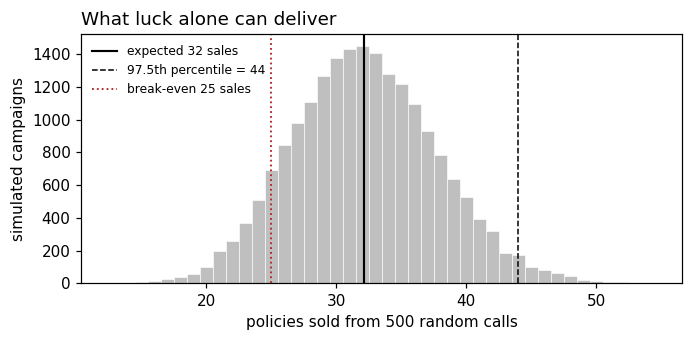

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.hist(sim_sales, bins=np.arange(sim_sales.min() - 0.5, sim_sales.max() + 1.5),
        color='0.75', edgecolor='white', linewidth=0.4)
ax.axvline(BUDGET * BASE_RATE, color='black', lw=1.4,
           label=f'expected {BUDGET * BASE_RATE:.0f} sales')
ax.axvline(hi, color='black', lw=1.0, ls='--',
           label=f'97.5th percentile = {hi:.0f}')
ax.axvline(BUDGET * break_even, color='firebrick', lw=1.2, ls=':',
           label=f'break-even {BUDGET * break_even:.0f} sales')
ax.set_xlabel('policies sold from 500 random calls')
ax.set_ylabel('simulated campaigns')
ax.set_title('What luck alone can deliver', loc='left')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## 5. The two helpers — `evaluate_shortlist()` is for the very end

`save_shortlist()` writes your ranked 500 to `shortlist.csv`.
`evaluate_shortlist()` breaks the seal. It takes your shortlist **in ranked
order**, best prospect first, and reports the hit rate, lift and profit at three
depths — so a single call also answers the budget-100 question in the README.

It deliberately does **not** give you an interval. Constructing one, and saying
what it is an interval about, is part of the deliverable (Chapter 5).

In [8]:
def save_shortlist(indices, path='shortlist.csv', label='my model'):
    """Write a ranked shortlist to CSV. `indices` must be original row labels
    of `Caravan`, best prospect first."""
    idx = np.asarray(indices)
    out = pd.DataFrame({'rank': np.arange(1, len(idx) + 1), 'row_label': idx,
                        'model': label})
    out.to_csv(path, index=False)
    print(f'wrote {len(out)} ranked prospects to {path}')
    return out


_EVAL_CALLS = []


def evaluate_shortlist(indices, label='my model', depths=(100, 250, 500)):
    """Score a ranked shortlist against the sealed outcomes. Call once.

    `indices` : exactly BUDGET original row labels of `Caravan`, all from the
                test set, no duplicates, ordered best prospect first.
    Returns a dict of the numbers your memo must quote.
    """
    idx = np.asarray(indices)
    if len(idx) != BUDGET:
        raise ValueError(f'shortlist has {len(idx)} rows; the budget is exactly {BUDGET}')
    if len(np.unique(idx)) != BUDGET:
        raise ValueError('shortlist contains duplicate prospects')
    stray = set(idx) - set(TEST_INDEX)
    if stray:
        raise ValueError(f'{len(stray)} shortlisted rows are not prospects '
                         f'(they are in the training set): {sorted(stray)[:5]} ...')

    _EVAL_CALLS.append(label)
    if len(_EVAL_CALLS) > 1:
        print(f'!! evaluation #{len(_EVAL_CALLS)} on the sealed set '
              f'(previous: {_EVAL_CALLS[:-1]}).')
        print('!! Your reported number is no longer an honest held-out estimate. '
              'Say so in the memo.\n')

    outcomes = y_test.loc[idx].to_numpy()          # ranked 0/1 outcomes, seal broken

    rows = []
    for k in depths:
        hits = int(outcomes[:k].sum())
        rate = hits / k
        rows.append({'calls': k, 'sales': hits, 'hit_rate': round(rate, 4),
                     'lift_vs_random': round(rate / BASE_RATE, 2),
                     'profit_EUR': int(campaign_profit(hits, k))})
    table = pd.DataFrame(rows).set_index('calls')

    print(f'SHORTLIST EVALUATION — {label}')
    print(f'  baseline purchase rate of the list: {BASE_RATE:.4f} ({BASE_RATE:.1%})')
    print(f'  random {BUDGET} calls would yield about {BUDGET * BASE_RATE:.1f} sales\n')
    print(table.to_string())

    head = table.loc[BUDGET]
    print(f'\nHEADLINE: {int(head["sales"])} sales from {BUDGET} calls '
          f'= {head["hit_rate"]:.1%} hit rate, {head["lift_vs_random"]:.2f}x random, '
          f'{head["profit_EUR"]:+,.0f} EUR.')
    print('Now build the interval yourself, and write the memo.')
    return {'label': label, 'table': table, 'ranked_outcomes': outcomes,
            'baseline_rate': BASE_RATE}


print('helpers ready:  save_shortlist(ranked_indices)  '
      'evaluate_shortlist(ranked_indices, label=...)')

helpers ready:  save_shortlist(ranked_indices)  evaluate_shortlist(ranked_indices, label=...)


**Smoke test.** The cell below runs the helpers on a *random* shortlist —
the baseline, which you are already allowed to know — so that you can see the
output format and be sure the functions work. It costs you nothing: the random
shortlist is not your answer. Overwrite `shortlist.csv` when you have one.

In [9]:
demo_rng = np.random.default_rng(99)
demo_shortlist = demo_rng.choice(TEST_INDEX, size=BUDGET, replace=False)

save_shortlist(demo_shortlist, label='random baseline (demo)')
print()
demo = evaluate_shortlist(demo_shortlist, label='random baseline (demo)')

_EVAL_CALLS.clear()   # the demo was on the baseline, not a model: it does not count

wrote 500 ranked prospects to shortlist.csv

SHORTLIST EVALUATION — random baseline (demo)
  baseline purchase rate of the list: 0.0642 (6.4%)
  random 500 calls would yield about 32.1 sales

       sales  hit_rate  lift_vs_random  profit_EUR
calls                                             
100        5     0.050            0.78           0
250       14     0.056            0.87         300
500       31     0.062            0.97        1200

HEADLINE: 31 sales from 500 calls = 6.2% hit rate, 0.97x random, +1,200 EUR.
Now build the interval yourself, and write the memo.


Exactly as advertised: a random shortlist lands at a lift of about
**1.0×** — the helper works, and that is the number to beat. The demo does not
spend your one evaluation, but every call you make from Step 5 onwards does, and
the helper will tell you if you make a second one.

---

Everything above this line is scaffolding. Everything below is yours.

## Step 1 — Decide what you are actually estimating

Before fitting anything, write two or three sentences in a markdown cell
answering: given the budget of 500 calls and the purchase rate you saw in
Section 1, **what quantity does the marketing team's decision depend on?** Name
it, and name the quantity it is *not*. Then state, in one line, how you will
compare two candidate models on the training set — a criterion you commit to
before seeing which model wins (Chapter 4, Chapter 5).

Write it down now. A criterion chosen after the results are in is not a
criterion.

## Step 2 — Fit candidate rankers on the training set

Fit at least **three** of the Chapter 4 classifiers to `X_train`, `y_train`:
logistic regression, LDA, QDA, naive Bayes, KNN. If you have reached Chapter 8,
a random forest or a boosted tree is a legitimate fourth candidate.

What each candidate must produce is a **continuous propensity score, not a hard
label** — `predict_proba(...)[:, 1]`, or a discriminant score. Remember that KNN
and any distance-based method need standardisation, and that `Pipeline` is how you
keep the scaler from seeing data it should not.

Beware one mechanical detail: a ranking is only as fine-grained as the scores
that produce it. Check how many *distinct* score values each model gives you
before you trust its ordering of 500 people.

## Step 3 — Choose one model, honestly, without the test set

Estimate each candidate's out-of-sample performance on your Step 1 criterion
using `KFold` or `StratifiedKFold` cross-validation **on the training set only**
(Chapter 5). Tune whatever needs tuning — the regularisation strength `C`, the
number of neighbours `k`, the feature subset — inside that same loop.

Report a small table: model, criterion value, and the standard error across
folds. Then pick one and say why. If two models are within a fold-to-fold
standard error of each other, say that too, and prefer the one you can explain
to a marketing manager.

## Step 4 — Rank the prospects and commit to 500

Refit your chosen model on the **full** training set, score all 1,822 prospects
in `X_test`, sort descending, and take the top 500 row labels. Break ties
explicitly — do not let `argsort` do it silently on your behalf.

Then, **before evaluating**, write down your prediction: how many sales do you
expect these 500 calls to produce, and what interval would you put around it?
Base it on your cross-validated estimate from Step 3. This is your
pre-registration, and comparing it with the realised number in Step 5 is worth
more than either number alone.

Save the shortlist with `save_shortlist(...)`.

## Step 5 — Break the seal, once

Call `evaluate_shortlist(your_ranked_500, label='...')` a single time.

Then attach uncertainty to the headline. Two defensible routes (Chapter 5):

- treat the 500 called prospects as 500 Bernoulli trials and put an exact or
  bootstrap interval around the realised hit rate — this quantifies *sampling
  variation in the outcomes of these 500 calls*;
- bootstrap or cross-validate the whole fit-and-rank procedure on the training
  set — this quantifies *how much the ranking itself would move* with different
  training data.

They answer different questions and give different widths. Say which one you
report, and which one the marketing team actually needs when they call a
*different* 500 prospects next quarter.

## Step 6 — The memo

Replace this cell's contents with your one-page memo to the marketing team. It
must contain every numbered item from the **What you must report** table in
[`README.md`](./README.md). Use this skeleton:

> **To:** Marketing, caravan line **From:** *your name* **Date:** *date*
> **Subject:** Recommended call list of 500 prospects
>
> **Recommendation.** *Call the 500 prospects in `shortlist.csv`. We expect
> ___ policies (___–___), a hit rate of ___% against ___% for a random list — a
> lift of ___×. At €10 per call and €200 per policy this returns €___ on a €5,000
> spend; the break-even hit rate is ___%.*
>
> **Method and why.** *Which model, which criterion it won on, its
> cross-validated value, and why not the alternatives.*
>
> **What the interval means.** *One or two sentences.*
>
> **Pre-registered versus realised.** *What you predicted in Step 4 and what you
> got.*
>
> **If the budget were 100 calls.** *One paragraph: the hit rate on the first 100
> names, total sales, profit per call versus the 500-call campaign, and which
> campaign you would recommend.*
>
> **Caveats.** *At least two. What would make this estimate wrong in
> deployment?*